Total baris setelah dropna: 2230
RR                 0
TAVG               0
RH_AVG             0
RR_Lag_44          0
Harga_Lag_1        0
Harga_Lag_7        0
Harga_Lag_30       0
Rolling_Mean_7     0
Rolling_Mean_14    0
Harga_Std_7        0
Bulan              0
Tahun              0
Is_Hari_Raya       0
dtype: int64

Train: 1784 baris | 2020-02-22 s/d 2025-01-09
Test:  446 baris  | 2025-01-10 s/d 2026-03-31
[0]	validation_0-rmse:19.75885
[50]	validation_0-rmse:6.20912
[100]	validation_0-rmse:6.02568
[150]	validation_0-rmse:6.09293
[200]	validation_0-rmse:6.11051
[250]	validation_0-rmse:6.11636
[299]	validation_0-rmse:6.14084

HASIL EKSPERIMEN + RR_Lag_44
RMSE : Rp 6,141
MAPE : 6.88%
Baseline sebelumnya → MAPE: 8.53%
Selisih             → +1.65%


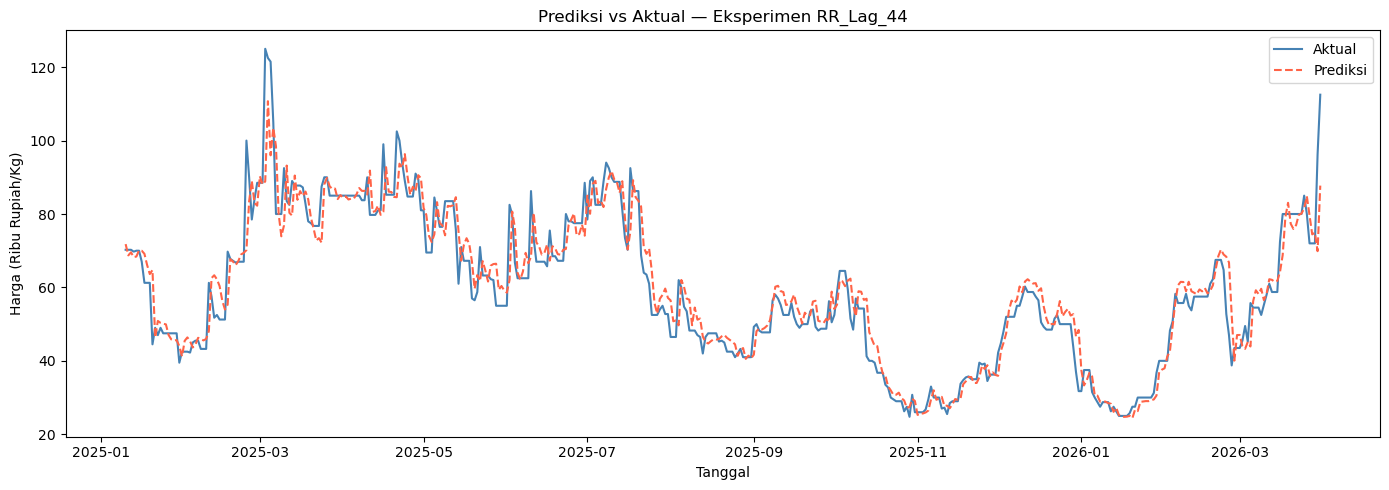

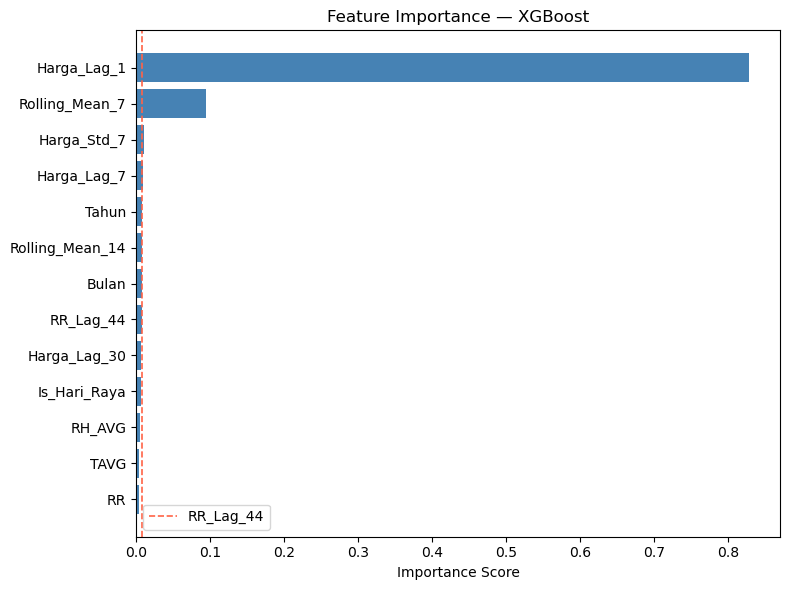

In [1]:
# ============================================================
# NOTEBOOK BARU — Eksperimen dengan fitur RR_Lag_44
# ============================================================

# --- 1. Import Library ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# --- 2. Load Dataset ---
df = pd.read_csv('clean_dataset_rica_manado_final.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)

# --- 3. Feature Engineering (semua fitur termasuk yang baru) ---
df['Rolling_Mean_7']  = df['Harga'].rolling(window=7).mean()
df['Rolling_Mean_14'] = df['Harga'].rolling(window=14).mean()
df['Harga_Std_7']     = df['Harga'].rolling(window=7).std()
df['Harga_Lag_30']    = df['Harga'].shift(30)
df['RR_Lag_44']       = df['RR'].shift(44)   # fitur baru

df = df.dropna().reset_index(drop=True)
print(f"Total baris setelah dropna: {len(df)}")

# --- 4. Definisi Fitur ---
feature_cols = [
    'RR', 'TAVG', 'RH_AVG',
    'RR_Lag_44',
    'Harga_Lag_1', 'Harga_Lag_7', 'Harga_Lag_30',
    'Rolling_Mean_7', 'Rolling_Mean_14', 'Harga_Std_7',
    'Bulan', 'Tahun', 'Is_Hari_Raya'
]

# Cek tidak ada missing value
print(df[feature_cols].isnull().sum())

# --- 5. Split Kronologis 80/20 ---
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

print(f"\nTrain: {len(train)} baris | {train['Tanggal'].min().date()} s/d {train['Tanggal'].max().date()}")
print(f"Test:  {len(test)} baris  | {test['Tanggal'].min().date()} s/d {test['Tanggal'].max().date()}")

# --- 6. Feature Scaling ---
scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols]  = scaler.transform(test[feature_cols])

X_train, y_train = train[feature_cols], train['Harga']
X_test,  y_test  = test[feature_cols],  test['Harga']

# --- 7. Training XGBoost ---
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

preds = model.predict(X_test)

# --- 8. Evaluasi ---
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"\n{'='*40}")
print(f"HASIL EKSPERIMEN + RR_Lag_44")
print(f"{'='*40}")
print(f"RMSE : Rp {rmse*1000:,.0f}")
print(f"MAPE : {mape:.2f}%")
print(f"{'='*40}")
print(f"Baseline sebelumnya → MAPE: 8.53%")
print(f"Selisih             → {8.53 - mape:+.2f}%")

# --- 9. Visualisasi Prediksi vs Aktual ---
hasil = pd.DataFrame({
    'Tanggal':  test['Tanggal'].values,
    'Aktual':   y_test.values,
    'Prediksi': preds
})

plt.figure(figsize=(14, 5))
plt.plot(hasil['Tanggal'], hasil['Aktual'],   label='Aktual',   color='steelblue', linewidth=1.5)
plt.plot(hasil['Tanggal'], hasil['Prediksi'], label='Prediksi', color='tomato',    linewidth=1.5, linestyle='--')
plt.title('Prediksi vs Aktual — Eksperimen RR_Lag_44')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Ribu Rupiah/Kg)')
plt.legend()
plt.tight_layout()
plt.savefig('eksperimen_rr_lag44.png', dpi=150)
plt.show()

# --- 10. Feature Importance ---
importance = pd.DataFrame({
    'Fitur':      feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance['Fitur'], importance['Importance'], color='steelblue')
plt.axvline(x=importance[importance['Fitur']=='RR_Lag_44']['Importance'].values[0],
            color='tomato', linestyle='--', linewidth=1.2, label='RR_Lag_44')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [3]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)  # Cross-validation khusus time series

xgb_tune = xgb.XGBRegressor(random_state=42, verbosity=0)

grid_search = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Parameter terbaik: {grid_search.best_params_}")

# Evaluasi dengan parameter terbaik
best_xgb = grid_search.best_estimator_
best_preds = best_xgb.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, best_preds))
best_mape = np.mean(np.abs((y_test - best_preds) / y_test)) * 100

print(f"\n{'='*50}")
print(f"{'Model':<30} {'MAPE':>8} {'RMSE':>12}")
print(f"{'='*50}")
print(f"{'XGBoost (default)':<30} {'6.88%':>8} {'Rp 6.141':>12}")
print(f"{'Random Forest':<30} {'5.93%':>8} {'Rp 5.806':>12}")
print(f"{'XGBoost (tuned)':<30} {f'{best_mape:.2f}%':>8} {f'Rp {best_rmse*1000:,.0f}':>12}")
print(f"{'='*50}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Parameter terbaik: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}

Model                              MAPE         RMSE
XGBoost (default)                 6.88%     Rp 6.141
Random Forest                     5.93%     Rp 5.806
XGBoost (tuned)                   7.72%     Rp 6,087


In [2]:
from sklearn.ensemble import RandomForestRegressor

# Pakai X_train, y_train, X_test, y_test yang sama persis
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mape = np.mean(np.abs((y_test - rf_preds) / y_test)) * 100

print(f"Random Forest → RMSE: Rp {rf_rmse*1000:,.0f} | MAPE: {rf_mape:.2f}%")
print(f"XGBoost       → RMSE: Rp 6.141           | MAPE: 6.88%")

Random Forest → RMSE: Rp 5,806 | MAPE: 5.93%
XGBoost       → RMSE: Rp 6.141           | MAPE: 6.88%


In [4]:
import joblib


joblib.dump(rf_model, 'model_rf_rica_manado_final.pkl')
joblib.dump(scaler,   'scaler_rica_manado_final.pkl')


joblib.dump(feature_cols, 'feature_cols.pkl')

print("Semua file tersimpan:")
print("  - model_rf_rica_manado_final.pkl")
print("  - scaler_rica_manado_final.pkl")
print("  - feature_cols.pkl")

Semua file tersimpan:
  - model_rf_rica_manado_final.pkl
  - scaler_rica_manado_final.pkl
  - feature_cols.pkl
